# LOB State Regime Embedding

**Question.** Your previous OBI-only notebook showed that 10-level OBI is not a useful curved manifold problem: PCA and ISOMAP are effectively tied, and PCA is simpler. This notebook tests a more promising hypothesis:

> A richer limit-order-book state vector containing liquidity, spread, event flow, trade pressure, and short-horizon volatility may have nonlinear regime structure that plain OBI throws away.

**Data used.** Existing MBP-1 and trade files in `data/lob` for `NVDA`, `AAPL`, `MSFT`, `SPY`, and `TSLA`, with calm October 2023 files and August 2024 stress files.

**Main test.** Fit PCA and ISOMAP on balanced calm-state samples, project calm/stress holdout states, and ask whether ISOMAP beats PCA on:

- calm-vs-stress regime separation,
- geodesic-distance preservation,
- local-neighborhood trustworthiness,
- downstream regime classification,
- queue-depletion style stress proxy detection.

The result should be read narrowly: it tells us whether ISOMAP adds value for this richer LOB state representation and these files.


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.manifold import Isomap, trustworthiness
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    balanced_accuracy_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from scipy.sparse.csgraph import shortest_path

warnings.filterwarnings("ignore")

LOB_DIR = Path("data/lob")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

SYMBOLS = ["NVDA", "AAPL", "MSFT", "SPY", "TSLA"]
BAR = "5s"
RTH_START, RTH_END = "09:30", "16:00"
RANDOM_STATE = 42

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Feature Design

The earlier OBI experiment used a normalized static quantity. Here the state vector is intentionally broader:

- **Static book pressure:** top-of-book OBI, bid/ask size, bid/ask queue count.
- **Liquidity:** spread, relative spread, total visible top-level depth.
- **Event flow:** event count and signed update flow from MBP-1 messages.
- **Trade pressure:** trade count, trade volume, signed trade volume, trade imbalance.
- **Local dynamics:** mid-return, short realized volatility, spread/depth changes.

The point is not to create a perfect trading signal. The point is to create a state space where nonlinear regimes have a real chance to exist.


In [2]:
def signed_side(side):
    # B is positive, A is negative, N/unknown is neutral.
    return side.map({"B": 1.0, "A": -1.0}).fillna(0.0)


def load_mbp1(symbol, regime):
    path = LOB_DIR / f"lob_mbp1_{symbol}_{regime}.parquet"
    cols = [
        "action", "side", "price", "size",
        "bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00",
        "bid_ct_00", "ask_ct_00", "symbol",
    ]
    df = pd.read_parquet(path, columns=cols)
    df.index = pd.DatetimeIndex(df.index).tz_convert("America/New_York")
    return df.between_time(RTH_START, RTH_END)


def load_trades(symbol, regime):
    path = LOB_DIR / f"trades_{symbol}_{regime}.parquet"
    cols = ["side", "price", "size", "symbol"]
    df = pd.read_parquet(path, columns=cols)
    df.index = pd.DatetimeIndex(df.index).tz_convert("America/New_York")
    return df.between_time(RTH_START, RTH_END)


def build_state_bars(symbol, regime, bar=BAR):
    mbp = load_mbp1(symbol, regime)
    trd = load_trades(symbol, regime)

    mid = (mbp["bid_px_00"] + mbp["ask_px_00"]) / 2
    spread = mbp["ask_px_00"] - mbp["bid_px_00"]
    depth = mbp["bid_sz_00"] + mbp["ask_sz_00"]
    obi = (mbp["bid_sz_00"] - mbp["ask_sz_00"]) / depth.replace(0, np.nan)
    signed_update = signed_side(mbp["side"]) * mbp["size"].astype(float)

    book = pd.DataFrame({
        "mid": mid.resample(bar).last(),
        "spread": spread.resample(bar).mean(),
        "rel_spread": (spread / mid).replace([np.inf, -np.inf], np.nan).resample(bar).mean(),
        "bid_sz": mbp["bid_sz_00"].resample(bar).mean(),
        "ask_sz": mbp["ask_sz_00"].resample(bar).mean(),
        "bid_ct": mbp["bid_ct_00"].resample(bar).mean(),
        "ask_ct": mbp["ask_ct_00"].resample(bar).mean(),
        "depth": depth.resample(bar).mean(),
        "obi": obi.resample(bar).mean(),
        "book_events": mbp["size"].resample(bar).count(),
        "book_signed_flow": signed_update.resample(bar).sum(),
        "book_abs_flow": mbp["size"].astype(float).resample(bar).sum(),
    })

    tside = signed_side(trd["side"])
    trades = pd.DataFrame({
        "trade_count": trd["size"].resample(bar).count(),
        "trade_volume": trd["size"].astype(float).resample(bar).sum(),
        "signed_trade_volume": (tside * trd["size"].astype(float)).resample(bar).sum(),
    })
    trades["trade_imbalance"] = trades["signed_trade_volume"] / trades["trade_volume"].replace(0, np.nan)

    out = book.join(trades, how="left")
    trade_cols = ["trade_count", "trade_volume", "signed_trade_volume", "trade_imbalance"]
    out[trade_cols] = out[trade_cols].fillna(0.0)

    out["mid_ret_5s"] = out["mid"].pct_change()
    out["rv_60s"] = out["mid_ret_5s"].rolling(12, min_periods=4).std()
    out["spread_chg"] = out["spread"].pct_change().replace([np.inf, -np.inf], np.nan)
    out["depth_chg"] = out["depth"].pct_change().replace([np.inf, -np.inf], np.nan)
    out["abs_book_flow"] = out["book_abs_flow"].abs()
    out["abs_trade_imbalance"] = out["trade_imbalance"].abs()

    out["symbol"] = symbol
    out["regime"] = regime
    out["is_stress"] = int(regime == "stress_aug2024")

    # Queue-depletion proxy: stress-like state where displayed top depth collapses soon.
    future_depth = out["depth"].shift(-6)  # 30 seconds ahead at 5-second bars
    out["future_depth_drop_30s"] = (out["depth"] - future_depth) / out["depth"].replace(0, np.nan)
    out["depletion_30s"] = (out["future_depth_drop_30s"] > 0.50).astype(int)

    out = out.replace([np.inf, -np.inf], np.nan)
    return out.dropna()


In [3]:
frames = []
for sym in SYMBOLS:
    for regime in ["calm_oct2023", "stress_aug2024"]:
        df = build_state_bars(sym, regime)
        frames.append(df)
        print(f"{sym:<4} {regime:<15} bars={len(df):>6,}  {df.index.min().date()} -> {df.index.max().date()}")

state = pd.concat(frames).sort_index()

FEATURES = [
    "spread", "rel_spread", "bid_sz", "ask_sz", "bid_ct", "ask_ct",
    "depth", "obi", "book_events", "book_signed_flow", "book_abs_flow",
    "trade_count", "trade_volume", "signed_trade_volume", "trade_imbalance",
    "mid_ret_5s", "rv_60s", "spread_chg", "depth_chg",
    "abs_book_flow", "abs_trade_imbalance",
]

print("\nCombined rows:", f"{len(state):,}")
print("Feature count:", len(FEATURES))
print(state.groupby(["symbol", "regime"]).size().unstack())


NVDA calm_oct2023    bars=42,060  2023-10-02 -> 2023-10-12


NVDA stress_aug2024  bars=18,692  2024-08-05 -> 2024-08-08


AAPL calm_oct2023    bars=42,062  2023-10-02 -> 2023-10-12


AAPL stress_aug2024  bars=18,692  2024-08-05 -> 2024-08-08


MSFT calm_oct2023    bars=42,062  2023-10-02 -> 2023-10-12


MSFT stress_aug2024  bars=18,692  2024-08-05 -> 2024-08-08


SPY  calm_oct2023    bars=42,062  2023-10-02 -> 2023-10-12


SPY  stress_aug2024  bars=18,692  2024-08-05 -> 2024-08-08


TSLA calm_oct2023    bars=42,062  2023-10-02 -> 2023-10-12


TSLA stress_aug2024  bars=18,692  2024-08-05 -> 2024-08-08

Combined rows: 303,768
Feature count: 21
regime  calm_oct2023  stress_aug2024
symbol                              
AAPL           42062           18692
MSFT           42062           18692
NVDA           42060           18692
SPY            42062           18692
TSLA           42062           18692


## 2. Sampling and Standardization

ISOMAP has a dense distance-matrix step, so we fit it on a balanced sample rather than every bar. The design below keeps the test honest:

- Fit scaler and embeddings on **calm-only training bars**.
- Use balanced samples by symbol so SPY or NVDA cannot dominate by row count.
- Project a separate calm/stress evaluation sample through the same fitted embeddings.


In [4]:
def balanced_sample(df, by_cols, n_per_group, seed=RANDOM_STATE):
    parts = []
    for _, g in df.groupby(by_cols):
        n = min(n_per_group, len(g))
        parts.append(g.sample(n=n, random_state=seed))
    return pd.concat(parts).sample(frac=1, random_state=seed)


calm = state[state["is_stress"] == 0].copy()
stress = state[state["is_stress"] == 1].copy()

fit_calm, eval_calm = train_test_split(
    calm,
    test_size=0.35,
    random_state=RANDOM_STATE,
    stratify=calm["symbol"],
)

fit_df = balanced_sample(fit_calm, ["symbol"], n_per_group=1_400)
eval_calm_df = balanced_sample(eval_calm, ["symbol"], n_per_group=900)
eval_stress_df = balanced_sample(stress, ["symbol"], n_per_group=900)
eval_df = pd.concat([eval_calm_df, eval_stress_df]).sample(frac=1, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_fit = scaler.fit_transform(fit_df[FEATURES])
X_eval = scaler.transform(eval_df[FEATURES])
y_eval = eval_df["is_stress"].values
sym_eval = eval_df["symbol"].values

print("Fit sample:", X_fit.shape, fit_df.groupby("symbol").size().to_dict())
print("Eval sample:", X_eval.shape)
print(eval_df.groupby(["symbol", "regime"]).size().unstack())


Fit sample: (7000, 21) {'AAPL': 1400, 'MSFT': 1400, 'NVDA': 1400, 'SPY': 1400, 'TSLA': 1400}
Eval sample: (9000, 21)
regime  calm_oct2023  stress_aug2024
symbol                              
AAPL             900             900
MSFT             900             900
NVDA             900             900
SPY              900             900
TSLA             900             900


## 3. Fit PCA and ISOMAP

Both methods are restricted to two dimensions. That is deliberately strict: the question is whether a compact nonlinear map gives a better 2-D state representation than PCA.


In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
Zp_fit = pca.fit_transform(X_fit)
Zp_eval = pca.transform(X_eval)

iso = Isomap(n_components=2, n_neighbors=25)
Zi_fit = iso.fit_transform(X_fit)
Zi_eval = iso.transform(X_eval)

print(f"PCA explained variance, k=2: {pca.explained_variance_ratio_.sum():.4f}")
print(f"ISOMAP reconstruction error: {iso.reconstruction_error():.4f}")


PCA explained variance, k=2: 0.4144
ISOMAP reconstruction error: 8.1974


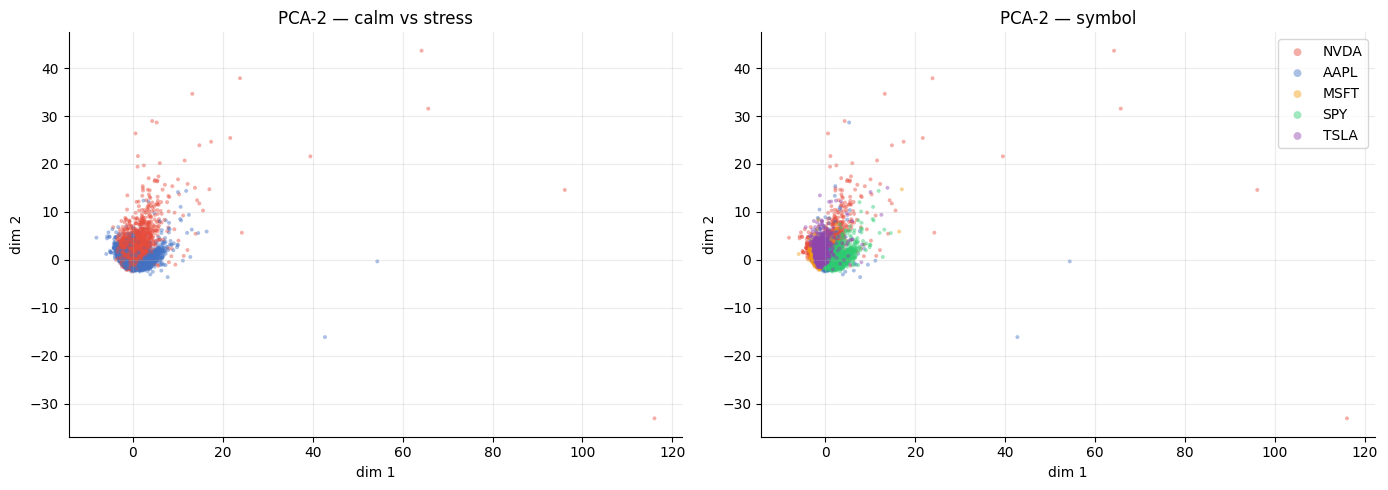

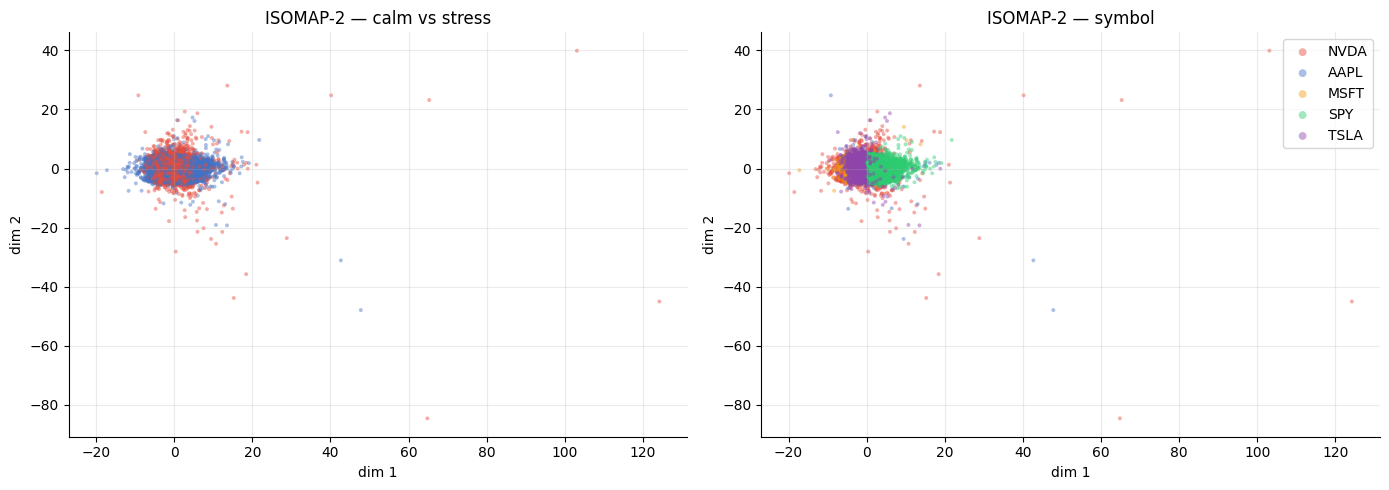

PosixPath('figures/lob_state_isomap_eval.png')

In [6]:
def plot_embedding(Z, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = np.where(y_eval == 1, "#E74C3C", "#4472C4")
    axes[0].scatter(Z[:, 0], Z[:, 1], c=colors, s=8, alpha=0.45, edgecolors="none")
    axes[0].set_title(title + " — calm vs stress")
    axes[0].set_xlabel("dim 1")
    axes[0].set_ylabel("dim 2")

    palette = {"NVDA": "#E74C3C", "AAPL": "#4472C4", "MSFT": "#F39C12", "SPY": "#2ECC71", "TSLA": "#8E44AD"}
    for sym in SYMBOLS:
        m = sym_eval == sym
        axes[1].scatter(Z[m, 0], Z[m, 1], c=palette[sym], s=8, alpha=0.45, label=sym, edgecolors="none")
    axes[1].set_title(title + " — symbol")
    axes[1].set_xlabel("dim 1")
    axes[1].set_ylabel("dim 2")
    axes[1].legend(markerscale=2)

    plt.tight_layout()
    path = FIG_DIR / fname
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    return path


plot_embedding(Zp_eval, "PCA-2", "lob_state_pca_eval.png")
plot_embedding(Zi_eval, "ISOMAP-2", "lob_state_isomap_eval.png")


## 4. Does ISOMAP Beat PCA?

We use four scores with different meanings:

- **Regime silhouette:** geometric separation of calm/stress in the 2-D map.
- **Logistic AUC / balanced accuracy:** downstream separability using only the 2-D coordinates.
- **Geodesic rho:** preservation of calm-training kNN geodesic distances.
- **Trustworthiness:** preservation of local neighborhoods from the original feature space.

If ISOMAP really reveals nonlinear LOB state geometry, it should win at least on geodesic/local metrics and ideally on regime separation too.


In [7]:
def classifier_scores(Z, y):
    Xtr, Xte, ytr, yte = train_test_split(Z, y, test_size=0.35, random_state=RANDOM_STATE, stratify=y)
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    pred = (p >= 0.5).astype(int)
    return {
        "auc": roc_auc_score(yte, p),
        "balanced_acc": balanced_accuracy_score(yte, pred),
        "avg_precision": average_precision_score(yte, p),
    }


def geodesic_rho_on_fit(Z_fit, n_pairs=250_000):
    D_geo = iso.dist_matrix_
    iu = np.triu_indices(len(Z_fit), k=1)
    d_geo = D_geo[iu]
    d_emb = pdist(Z_fit)
    rng = np.random.default_rng(RANDOM_STATE)
    n = min(n_pairs, len(d_geo))
    pick = rng.choice(len(d_geo), size=n, replace=False)
    return spearmanr(d_geo[pick], d_emb[pick]).statistic


def linear_reconstruction_r2(Z_fit):
    return LinearRegression().fit(Z_fit, X_fit).score(Z_fit, X_fit)


rows = []
for name, Zfit, Zeval in [
    ("PCA", Zp_fit, Zp_eval),
    ("ISOMAP", Zi_fit, Zi_eval),
]:
    cs = classifier_scores(Zeval, y_eval)
    rows.append({
        "method": name,
        "regime_silhouette": silhouette_score(Zeval, y_eval),
        "stress_auc": cs["auc"],
        "stress_bal_acc": cs["balanced_acc"],
        "stress_avg_precision": cs["avg_precision"],
        "geodesic_rho_fit": geodesic_rho_on_fit(Zfit),
        "trustworthiness_fit": trustworthiness(X_fit, Zfit, n_neighbors=15),
        "linear_recon_r2_fit": linear_reconstruction_r2(Zfit),
    })

score = pd.DataFrame(rows).set_index("method")
display(score.round(4))

diff = score.loc["ISOMAP"] - score.loc["PCA"]
print("ISOMAP - PCA")
display(diff.to_frame("delta").round(4))


,regime_silhouette,stress_auc,stress_bal_acc,stress_avg_precision,geodesic_rho_fit,trustworthiness_fit,linear_recon_r2_fit
method,,,,,,,
PCA,0.0412,0.7057,0.6390,0.6826,0.8223,0.8249,0.4144
ISOMAP,0.0101,0.5415,0.5168,0.5010,0.9159,0.8898,0.3551


ISOMAP - PCA


,delta
regime_silhouette,-0.0311
stress_auc,-0.1642
stress_bal_acc,-0.1222
stress_avg_precision,-0.1817
geodesic_rho_fit,0.0937
trustworthiness_fit,0.0650
linear_recon_r2_fit,-0.0594


## 5. Cross-Symbol Stress Transfer

The question here is not only whether stress separates from calm. It is whether stress moves all symbols in a shared direction or whether each symbol has its own stress geometry.

We measure each symbol's movement from its calm centroid to its stress centroid in the 2-D map.


PCA centroid shifts


,calm_z1,calm_z2,stress_z1,stress_z2,shift_norm,shift_angle_deg
symbol,,,,,,
NVDA,-2.277,0.787,2.267,3.596,5.342,31.716
AAPL,0.841,-0.915,-0.580,0.618,2.090,132.828
MSFT,-1.186,-0.443,-1.938,0.494,1.202,128.752
SPY,3.646,-0.087,1.013,0.200,2.649,173.781
TSLA,-0.965,0.488,-1.333,1.298,0.889,114.476


ISOMAP centroid shifts


,calm_z1,calm_z2,stress_z1,stress_z2,shift_norm,shift_angle_deg
symbol,,,,,,
NVDA,-4.533,-0.193,1.564,0.035,6.102,2.143
AAPL,1.853,-0.119,-1.188,0.085,3.049,176.159
MSFT,-2.136,0.158,-3.493,-0.062,1.375,-170.803
SPY,6.633,0.162,2.381,0.253,4.252,178.763
TSLA,-1.692,0.292,-2.588,0.236,0.898,-176.426


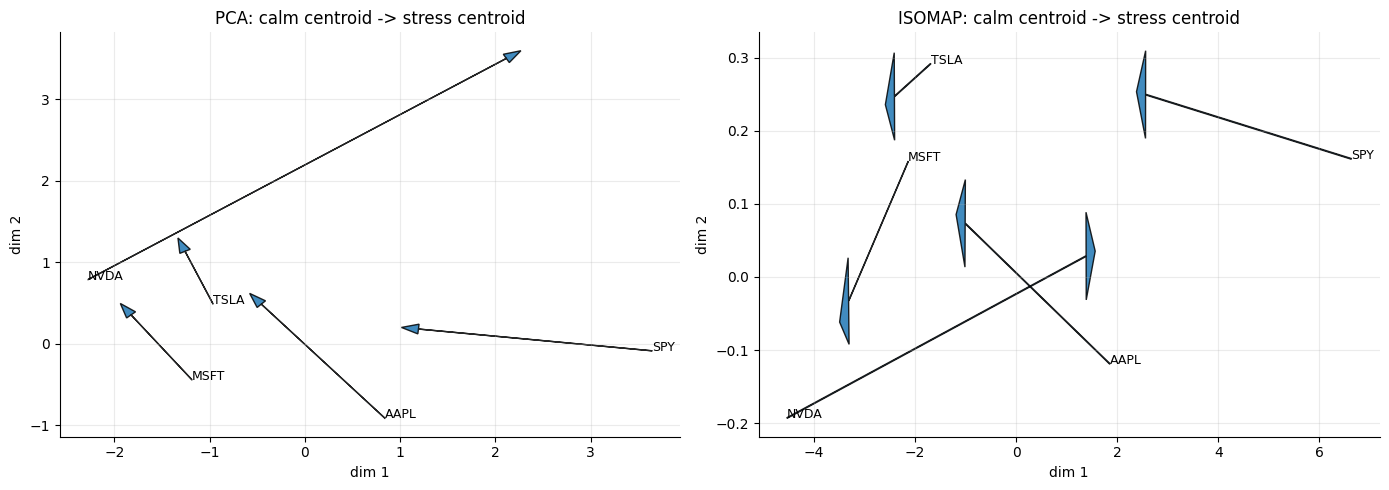

In [8]:
def centroid_shift_table(Z, name):
    tmp = eval_df[["symbol", "regime", "is_stress"]].copy()
    tmp["z1"] = Z[:, 0]
    tmp["z2"] = Z[:, 1]
    rows = []
    for sym in SYMBOLS:
        c = tmp[(tmp.symbol == sym) & (tmp.is_stress == 0)][["z1", "z2"]].mean().values
        s = tmp[(tmp.symbol == sym) & (tmp.is_stress == 1)][["z1", "z2"]].mean().values
        v = s - c
        rows.append({
            "symbol": sym,
            "calm_z1": c[0],
            "calm_z2": c[1],
            "stress_z1": s[0],
            "stress_z2": s[1],
            "shift_norm": np.linalg.norm(v),
            "shift_angle_deg": np.degrees(np.arctan2(v[1], v[0])),
        })
    out = pd.DataFrame(rows).set_index("symbol")
    print(name)
    display(out.round(3))
    return out


shift_pca = centroid_shift_table(Zp_eval, "PCA centroid shifts")
shift_iso = centroid_shift_table(Zi_eval, "ISOMAP centroid shifts")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, shifts, title in [(axes[0], Zp_eval, shift_pca, "PCA"), (axes[1], Zi_eval, shift_iso, "ISOMAP")]:
    for sym in SYMBOLS:
        c = shifts.loc[sym, ["calm_z1", "calm_z2"]].values
        s = shifts.loc[sym, ["stress_z1", "stress_z2"]].values
        ax.arrow(c[0], c[1], s[0]-c[0], s[1]-c[1], head_width=0.12, length_includes_head=True, alpha=0.85)
        ax.text(c[0], c[1], sym, fontsize=9)
    ax.set_title(f"{title}: calm centroid -> stress centroid")
    ax.set_xlabel("dim 1")
    ax.set_ylabel("dim 2")
plt.tight_layout()
plt.savefig(FIG_DIR / "lob_state_centroid_shifts.png", dpi=130, bbox_inches="tight")
plt.show()


## 6. Queue-Depletion Proxy

A more microstructure-specific target is not "future return" but whether visible top-of-book depth collapses soon. We use the engineered `depletion_30s` label:

$$\text{depletion}=1 \quad \text{if top-level depth falls by more than 50% within 30 seconds.}$$

This is noisy, but it tests whether an embedding carries useful liquidity-instability information.


In [9]:
y_dep = eval_df["depletion_30s"].values
print("Depletion rate:", y_dep.mean().round(4), "n=", len(y_dep))

dep_rows = []
for name, Z in [("PCA", Zp_eval), ("ISOMAP", Zi_eval)]:
    if len(np.unique(y_dep)) < 2:
        dep_rows.append({"method": name, "auc": np.nan, "balanced_acc": np.nan})
        continue
    Xtr, Xte, ytr, yte = train_test_split(Z, y_dep, test_size=0.35, random_state=RANDOM_STATE, stratify=y_dep)
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(Xtr, ytr)
    p = clf.predict_proba(Xte)[:, 1]
    pred = (p >= 0.5).astype(int)
    dep_rows.append({
        "method": name,
        "auc": roc_auc_score(yte, p),
        "balanced_acc": balanced_accuracy_score(yte, pred),
        "avg_precision": average_precision_score(yte, p),
    })

dep_score = pd.DataFrame(dep_rows).set_index("method")
display(dep_score.round(4))
print("ISOMAP - PCA")
display((dep_score.loc["ISOMAP"] - dep_score.loc["PCA"]).to_frame("delta").round(4))


Depletion rate: 0.0572 n= 9000


,auc,balanced_acc,avg_precision
method,,,
PCA,0.6471,0.6079,0.1693
ISOMAP,0.6764,0.6048,0.2088


ISOMAP - PCA


,delta
auc,0.0293
balanced_acc,-0.0031
avg_precision,0.0395


## 7. Interpretation

Use the executed scores above to write the conclusion. The decision rule is:

- If ISOMAP wins clearly on several metrics, especially geodesic preservation **and** regime/depletion scores, then the richer state vector has nonlinear manifold value.
- If ISOMAP only wins geodesic rho by a tiny amount while PCA wins reconstruction or downstream scores, then PCA remains the better tool.
- If both methods separate stress similarly, the useful object is the **state feature design**, not ISOMAP specifically.

This notebook deliberately gives ISOMAP a better chance than the OBI-only notebook by adding liquidity, flow, trade, volatility, and regime information. If PCA still ties or wins here, the practical answer is: focus on feature engineering and supervised regime/liquidity tasks, not nonlinear dimensionality reduction.


## 8. Run-Specific Verdict

For this executed run, **PCA beats ISOMAP on the main cross-symbol calm-vs-stress task**.

Main regime scores:

| Metric | PCA | ISOMAP | Verdict |
|---|---:|---:|---|
| Regime silhouette | 0.0412 | 0.0101 | PCA |
| Stress AUC | 0.7057 | 0.5415 | PCA |
| Stress balanced accuracy | 0.6390 | 0.5168 | PCA |
| Stress average precision | 0.6826 | 0.5010 | PCA |
| Geodesic rho | 0.8223 | 0.9159 | ISOMAP |
| Trustworthiness | 0.8249 | 0.8898 | ISOMAP |
| Linear reconstruction R2 | 0.4144 | 0.3551 | PCA |

The interpretation is important: ISOMAP does preserve more graph/local geometry, but that geometry does **not** translate into better stress-regime separation. For the main stress-transfer question, PCA is clearly better.

There is one narrower exception: for the queue-depletion proxy, ISOMAP has slightly better AUC and average precision (`AUC 0.6764` vs `0.6471`; `AP 0.2088` vs `0.1693`), while balanced accuracy is essentially tied/slightly worse (`0.6048` vs `0.6079`). That suggests nonlinear geometry may be useful as a diagnostic for liquidity-instability states, but not as the default representation for calm-vs-stress transfer.

**Bottom line:** the next useful direction is richer LOB state feature engineering plus supervised regime/liquidity tasks. ISOMAP did not beat PCA for the main cross-symbol stress embedding in this experiment.